In [1]:
# ── Install any missing packages ──
# !pip install torchcam grad-cam scikit-learn seaborn matplotlib Pillow

import os, time, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Subset

from sklearn.metrics import (classification_report, confusion_matrix,
                              cohen_kappa_score, accuracy_score,
                              jaccard_score, f1_score)
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')

# ── Reproducibility ──
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device Configuration ──
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"✅ PyTorch version : {torch.__version__}")
print(f"✅ Compute device  : {device}")
if torch.cuda.is_available():
    print(f"   GPU Name       : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✅ PyTorch version : 2.10.0+cu128
✅ Compute device  : cuda:0
   GPU Name       : Tesla T4
   VRAM           : 15.6 GB


In [2]:
# ── Download EuroSAT RGB Dataset ──
import os

if not os.path.exists('EuroSAT_RGB'):
    print("Downloading EuroSAT RGB dataset from Zenodo...")
    os.system("wget -q https://zenodo.org/record/7711810/files/EuroSAT_RGB.zip -O EuroSAT_RGB.zip")
    os.system("unzip -q EuroSAT_RGB.zip")
    os.system("rm -f EuroSAT_RGB.zip")
    print("✅ Dataset downloaded and extracted.")
else:
    print("✅ Dataset already exists locally.")

# ── Locate the DATA_PATH ──
DATA_PATH = None
for root, dirs, files in os.walk("."):
    if 'Forest' in dirs:
        DATA_PATH = root
        break

if DATA_PATH:
    CLASS_NAMES = sorted(os.listdir(DATA_PATH))
    print(f"\n📁 DATA_PATH     : {DATA_PATH}")
    print(f"🏷️  Classes found : {CLASS_NAMES}")
    print(f"📊 Total classes : {len(CLASS_NAMES)}")
else:
    print("❌ Dataset not found. Check download above.")


✅ Dataset downloaded and extracted.

📁 DATA_PATH     : ./EuroSAT_RGB
🏷️  Classes found : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
📊 Total classes : 10


📸 Total images  : 27000
⚖️  Class balance : Imbalanced



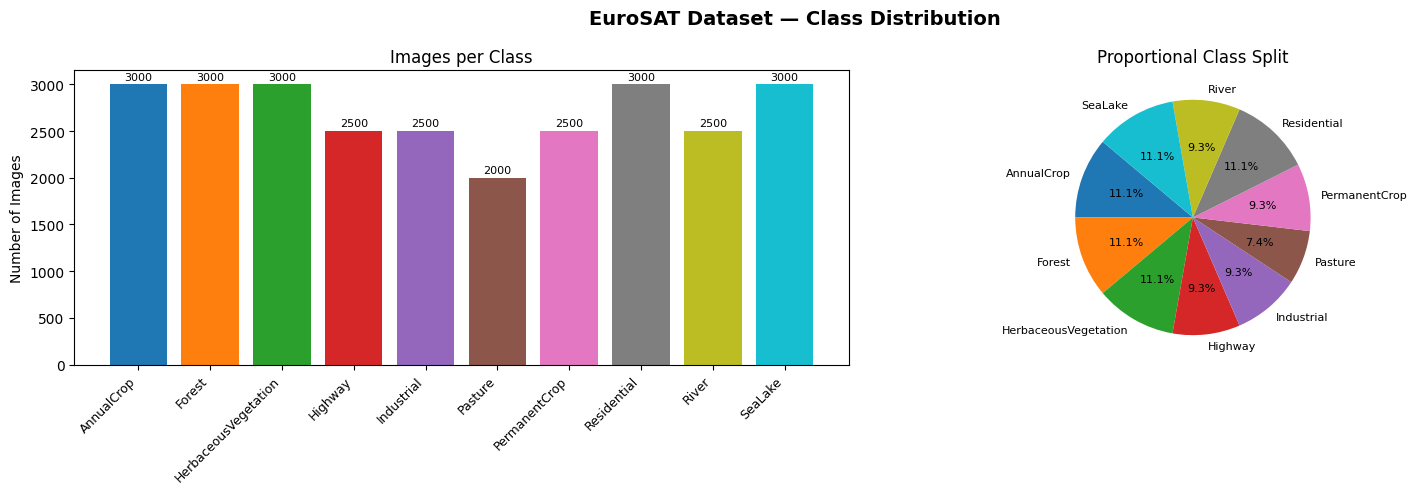

✅ Class distribution saved.


In [3]:
# ── Count images per class ──
class_counts = {}
for cls in CLASS_NAMES:
    cls_path = os.path.join(DATA_PATH, cls)
    class_counts[cls] = len([f for f in os.listdir(cls_path)
                              if f.lower().endswith(('.jpg','.png','.tif'))])

total_images = sum(class_counts.values())
print(f"📸 Total images  : {total_images}")
print(f"⚖️  Class balance : {'Balanced' if max(class_counts.values())-min(class_counts.values()) < 500 else 'Imbalanced'}\n")

# ── Plot class distribution ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('EuroSAT Dataset — Class Distribution', fontsize=14, fontweight='bold')

# Bar chart
colors = plt.cm.tab10(np.linspace(0, 1, len(CLASS_NAMES)))
axes[0].bar(range(len(CLASS_NAMES)), list(class_counts.values()), color=colors)
axes[0].set_xticks(range(len(CLASS_NAMES)))
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Images per Class')
for i, v in enumerate(class_counts.values()):
    axes[0].text(i, v + 30, str(v), ha='center', va='bottom', fontsize=8)

# Pie chart
axes[1].pie(list(class_counts.values()), labels=CLASS_NAMES,
            autopct='%1.1f%%', colors=colors, startangle=140,
            textprops={'fontsize': 8})
axes[1].set_title('Proportional Class Split')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Class distribution saved.")


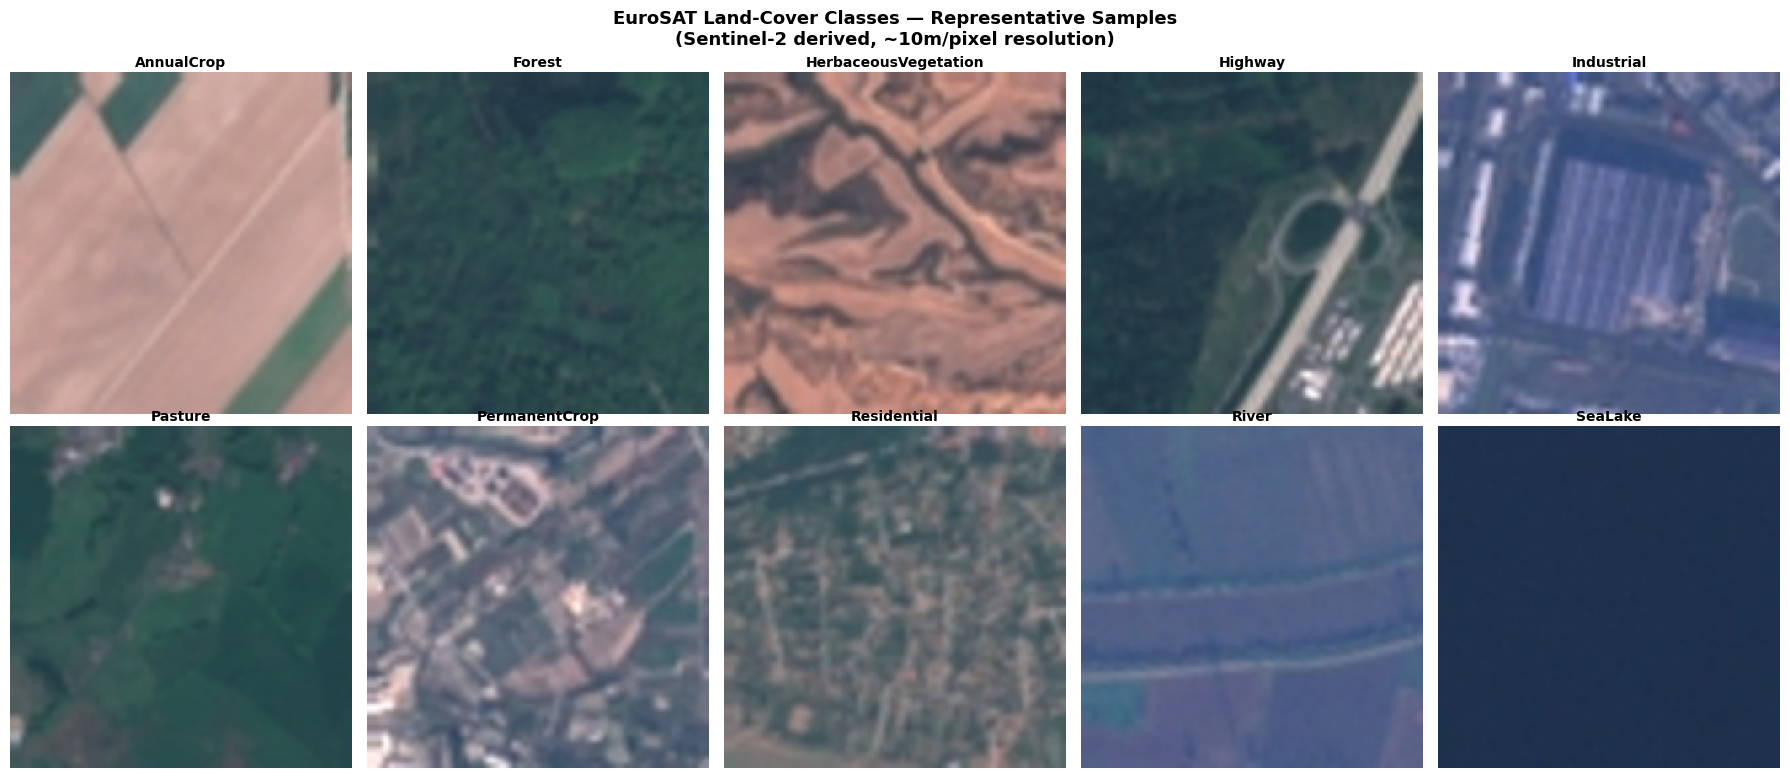

✅ Sample grid saved.


In [4]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('EuroSAT Land-Cover Classes — Representative Samples\n(Sentinel-2 derived, ~10m/pixel resolution)',
             fontsize=13, fontweight='bold')

for idx, cls in enumerate(CLASS_NAMES):
    ax = axes[idx // 5][idx % 5]
    cls_dir = os.path.join(DATA_PATH, cls)
    # Pick the 3rd image to get a typical sample
    img_files = sorted(os.listdir(cls_dir))
    img_path = os.path.join(cls_dir, img_files[2])
    img = Image.open(img_path).resize((128, 128))
    ax.imshow(img)
    ax.set_title(cls, fontsize=10, fontweight='bold', pad=4)
    ax.axis('off')

plt.tight_layout()
plt.savefig('class_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample grid saved.")


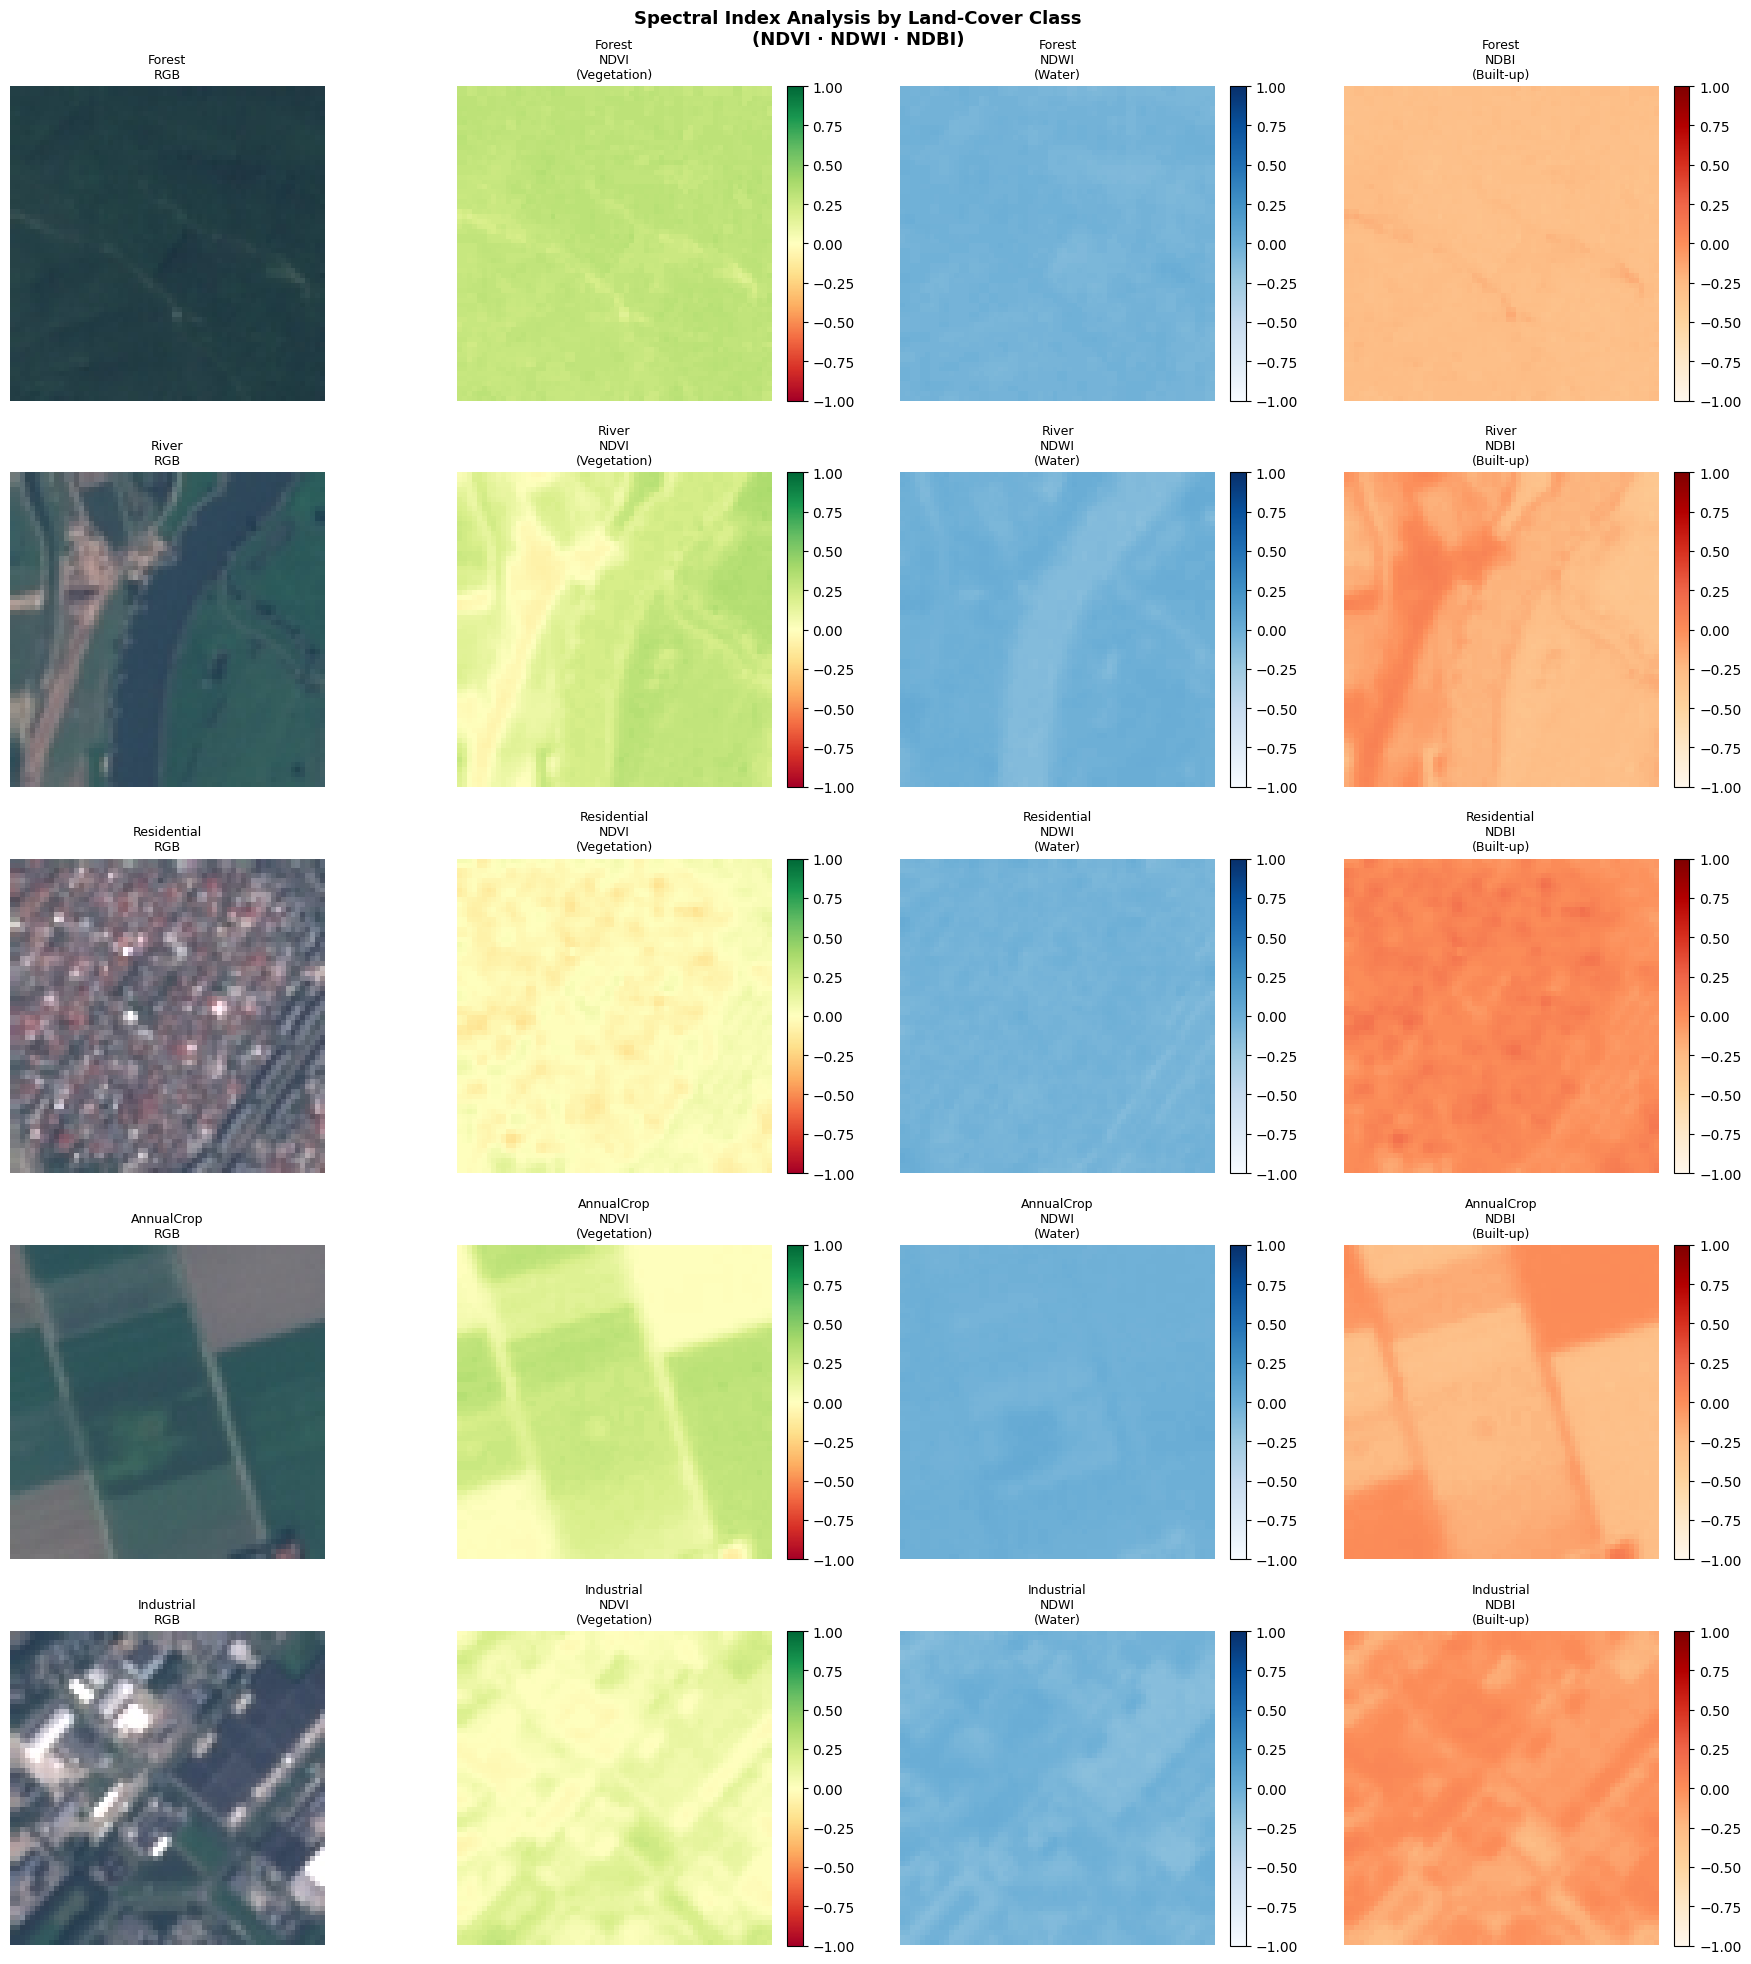

✅ Spectral index analysis saved.


In [5]:
def compute_spectral_indices(img_array):
    """
    Compute approximate spectral indices from RGB.
    R=img[0], G=img[1], B=img[2] (normalized 0-1)
    In true multispectral: R~Red, G~Green, NIR from separate band.
    Here we use RGB channels as proxies for demonstration.
    """
    img = img_array.astype(np.float32) / 255.0
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]
    eps = 1e-8

    ndvi  = (G - R) / (G + R + eps)          # Vegetation index proxy
    ndwi  = (G - B) / (G + B + eps)          # Water index proxy
    ndbi  = (R - G) / (R + G + eps)          # Built-up index proxy

    return ndvi, ndwi, ndbi

# ── Compare spectral signatures across 5 classes ──
compare_classes = ['Forest', 'River', 'Residential', 'AnnualCrop', 'Industrial']

fig, axes = plt.subplots(len(compare_classes), 4, figsize=(18, 4*len(compare_classes)))
fig.suptitle('Spectral Index Analysis by Land-Cover Class\n(NDVI · NDWI · NDBI)',
             fontsize=13, fontweight='bold')

for row, cls in enumerate(compare_classes):
    cls_dir = os.path.join(DATA_PATH, cls)
    img_path = os.path.join(cls_dir, sorted(os.listdir(cls_dir))[5])
    img = np.array(Image.open(img_path).resize((64, 64)))

    ndvi, ndwi, ndbi = compute_spectral_indices(img)

    axes[row][0].imshow(img)
    axes[row][0].set_title(f'{cls}\nRGB', fontsize=9)
    axes[row][0].axis('off')

    for col, (index, cmap, name) in enumerate(zip(
        [ndvi, ndwi, ndbi],
        ['RdYlGn', 'Blues', 'OrRd'],
        ['NDVI\n(Vegetation)', 'NDWI\n(Water)', 'NDBI\n(Built-up)']
    )):
        im = axes[row][col+1].imshow(index, cmap=cmap, vmin=-1, vmax=1)
        axes[row][col+1].set_title(f'{cls}\n{name}', fontsize=9)
        axes[row][col+1].axis('off')
        plt.colorbar(im, ax=axes[row][col+1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('spectral_indices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Spectral index analysis saved.")


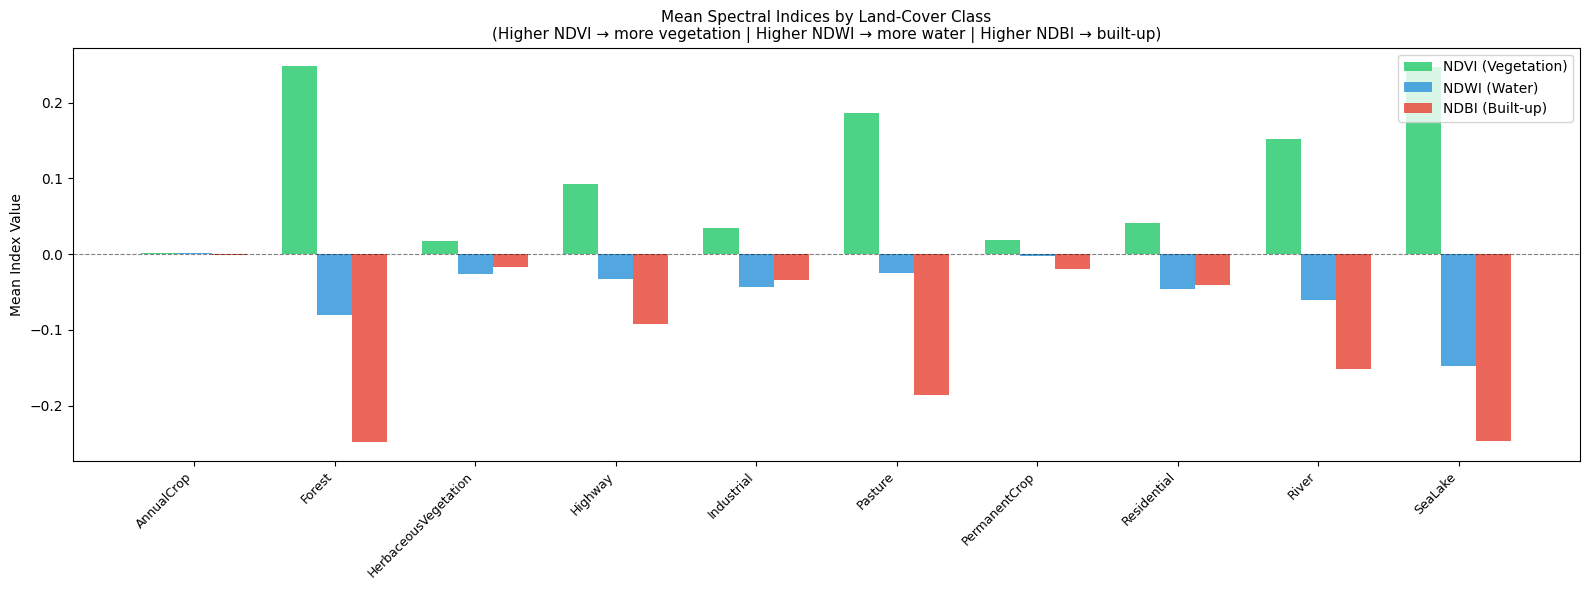

✅ Mean spectral indices plotted.


In [6]:
mean_indices = {cls: {'NDVI': [], 'NDWI': [], 'NDBI': []} for cls in CLASS_NAMES}

for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATA_PATH, cls)
    # Sample 50 images per class for speed
    files = sorted(os.listdir(cls_dir))[:50]
    for fn in files:
        fp = os.path.join(cls_dir, fn)
        img = np.array(Image.open(fp).resize((64, 64)))
        ndvi, ndwi, ndbi = compute_spectral_indices(img)
        mean_indices[cls]['NDVI'].append(ndvi.mean())
        mean_indices[cls]['NDWI'].append(ndwi.mean())
        mean_indices[cls]['NDBI'].append(ndbi.mean())

# ── Plot mean indices ──
x = np.arange(len(CLASS_NAMES))
w = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - w, [np.mean(mean_indices[c]['NDVI']) for c in CLASS_NAMES], w,
       label='NDVI (Vegetation)', color='#2ECC71', alpha=0.85)
ax.bar(x,     [np.mean(mean_indices[c]['NDWI']) for c in CLASS_NAMES], w,
       label='NDWI (Water)',     color='#3498DB', alpha=0.85)
ax.bar(x + w, [np.mean(mean_indices[c]['NDBI']) for c in CLASS_NAMES], w,
       label='NDBI (Built-up)',  color='#E74C3C', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean Index Value')
ax.set_title('Mean Spectral Indices by Land-Cover Class\n(Higher NDVI → more vegetation | Higher NDWI → more water | Higher NDBI → built-up)',
             fontsize=11)
ax.legend(loc='upper right')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('mean_spectral_indices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Mean spectral indices plotted.")


In [7]:
IMG_SIZE  = 64
BATCH_SIZE = 32

# ── Training Augmentation (ISRO-relevant transforms) ──
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),           # Satellite imagery has no fixed orientation
    transforms.RandomRotation(degrees=90),            # Orbital angle variation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),  # Sensor calibration noise
    transforms.RandomGrayscale(p=0.05),              # Simulate multispectral edge cases
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# ── Validation / Test Transform (no augmentation) ──
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# ── Load Dataset & Split (70% train, 15% val, 15% test) ──
full_dataset = datasets.ImageFolder(root=DATA_PATH)
n = len(full_dataset)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

train_data, val_data, test_data = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply transforms
train_data.dataset.transform = train_transform
val_data.dataset.transform   = val_transform
test_data.dataset.transform  = val_transform

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

NUM_CLASSES = len(full_dataset.classes)
CLASS_NAMES = full_dataset.classes

print(f"📊 Dataset split:")
print(f"   Train      : {len(train_data):,} images ({len(train_data)/n*100:.0f}%)")
print(f"   Validation : {len(val_data):,}  images ({len(val_data)/n*100:.0f}%)")
print(f"   Test       : {len(test_data):,}  images ({len(test_data)/n*100:.0f}%)")
print(f"   Classes    : {NUM_CLASSES}")


📊 Dataset split:
   Train      : 18,900 images (70%)
   Validation : 4,050  images (15%)
   Test       : 4,050  images (15%)
   Classes    : 10


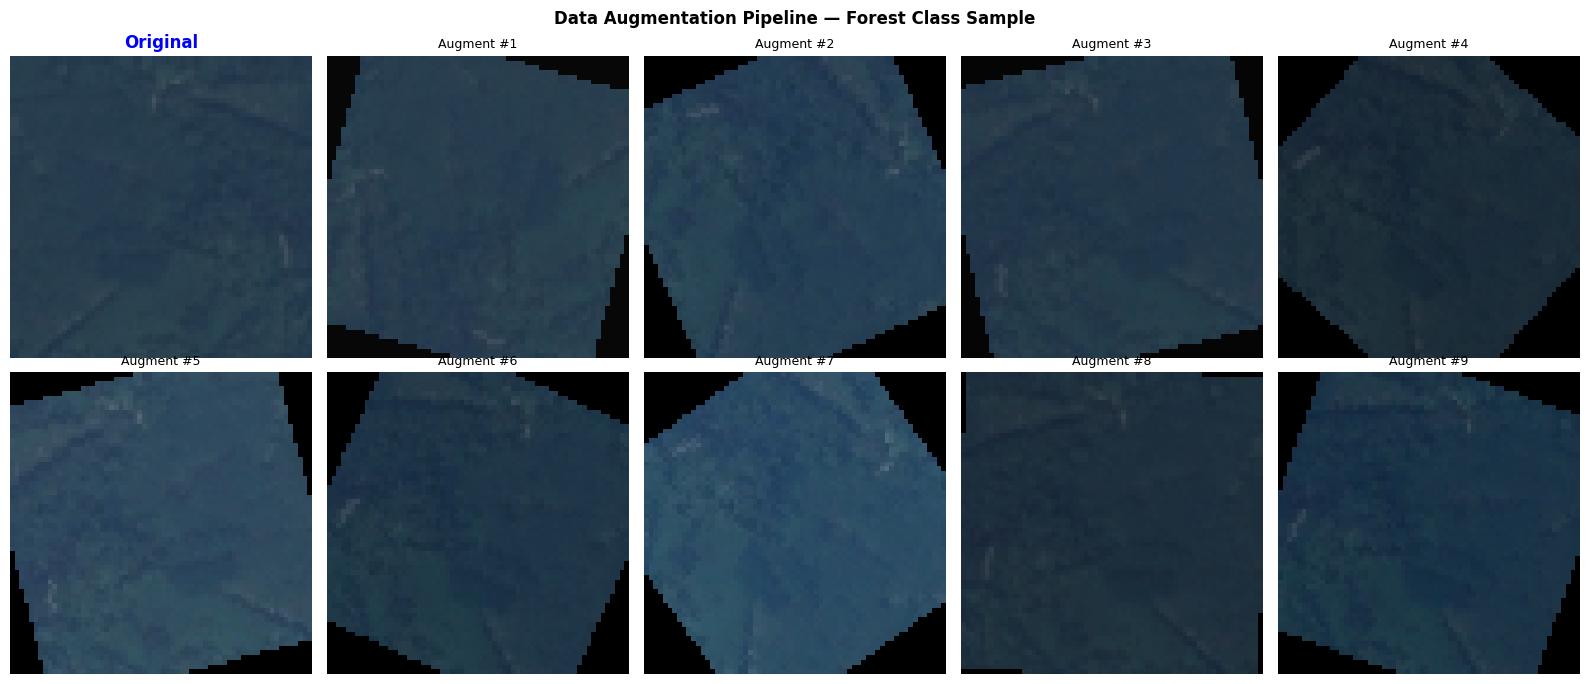

✅ Augmentation grid saved.


In [8]:
# ── Show same image with different augmentations ──
aug_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(degrees=90),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
])

# Load a raw image
raw_path = os.path.join(DATA_PATH, 'Forest', sorted(os.listdir(os.path.join(DATA_PATH,'Forest')))[0])
raw_img  = Image.open(raw_path).resize((64, 64))

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Data Augmentation Pipeline — Forest Class Sample',
             fontsize=12, fontweight='bold')

axes[0][0].imshow(raw_img)
axes[0][0].set_title('Original', fontweight='bold', color='blue')
axes[0][0].axis('off')

for i in range(1, 10):
    row, col = divmod(i, 5)
    aug_img  = aug_transform(raw_img)
    axes[row][col].imshow(aug_img)
    axes[row][col].set_title(f'Augment #{i}', fontsize=9)
    axes[row][col].axis('off')

plt.tight_layout()
plt.savefig('augmentation_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Augmentation grid saved.")


In [9]:
class SatelliteCNN(nn.Module):
    """
    Custom CNN baseline for satellite land-cover classification.
    Architecture inspired by VGG-style blocks adapted for 64x64 EO imagery.
    """
    def __init__(self, num_classes=10):
        super(SatelliteCNN, self).__init__()

        # Block 1 — Low-level spatial features (edges, textures)
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.1)   # 64 → 32
        )
        # Block 2 — Mid-level spectral patterns
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.1)   # 32 → 16
        )
        # Block 3 — High-level semantic features
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2)   # 16 → 8
        )
        # Global Average Pooling (reduces spatial dim → 1x1, robust to resolution)
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        return self.classifier(x)

cnn_model = SatelliteCNN(num_classes=NUM_CLASSES).to(device)

# ── Model Summary ──
total_params = sum(p.numel() for p in cnn_model.parameters())
train_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"📐 Custom CNN Architecture:")
print(f"   Total Parameters     : {total_params:,}")
print(f"   Trainable Parameters : {train_params:,}")
print(f"   Model Size (est.)    : {total_params * 4 / 1e6:.2f} MB")


📐 Custom CNN Architecture:
   Total Parameters     : 323,498
   Trainable Parameters : 323,498
   Model Size (est.)    : 1.29 MB


In [10]:
def build_resnet18(num_classes, freeze_backbone=True):
    """ResNet18 with custom classifier head for satellite imagery."""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace classifier with domain-adapted head
    in_features = model.fc.in_features  # 512
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    return model

resnet_model = build_resnet18(NUM_CLASSES, freeze_backbone=True).to(device)

total_params  = sum(p.numel() for p in resnet_model.parameters())
train_params  = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"📐 ResNet18 Transfer Learning:")
print(f"   Total Parameters     : {total_params:,}")
print(f"   Trainable Parameters : {train_params:,} (frozen backbone)")
print(f"   Model Size (est.)    : {total_params * 4 / 1e6:.2f} MB")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 31.9MB/s]

📐 ResNet18 Transfer Learning:
   Total Parameters     : 11,310,410
   Trainable Parameters : 133,898 (frozen backbone)
   Model Size (est.)    : 45.24 MB


In [11]:
def build_efficientnet(num_classes):
    """EfficientNet-B0 with custom head for satellite imagery."""
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    # Freeze all layers initially
    for param in model.parameters():
        param.requires_grad = False

    # Replace classifier
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Linear(256, num_classes)
    )
    return model

effnet_model = build_efficientnet(NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in effnet_model.parameters())
train_params = sum(p.numel() for p in effnet_model.parameters() if p.requires_grad)
print(f"📐 EfficientNet-B0:")
print(f"   Total Parameters     : {total_params:,}")
print(f"   Trainable Parameters : {train_params:,} (frozen backbone)")
print(f"   Model Size (est.)    : {total_params * 4 / 1e6:.2f} MB")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 189MB/s]

📐 EfficientNet-B0:
   Total Parameters     : 4,338,054
   Trainable Parameters : 330,506 (frozen backbone)
   Model Size (est.)    : 17.35 MB


In [12]:
class EarlyStopping:
    """Early stopping based on validation loss."""
    def __init__(self, patience=5, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


def train_model(model, model_name, train_loader, val_loader,
                num_epochs=15, lr=1e-3, device=device):
    """
    Full training loop with validation, LR scheduling, early stopping.
    Returns history dict with loss/accuracy curves.
    """
    criterion    = nn.CrossEntropyLoss(label_smoothing=0.1)  # Label smoothing improves calibration
    optimizer    = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                               lr=lr, weight_decay=1e-4)
    scheduler    = optim.lr_scheduler.OneCycleLR(
                       optimizer, max_lr=lr,
                       steps_per_epoch=len(train_loader),
                       epochs=num_epochs, pct_start=0.3)
    early_stop   = EarlyStopping(patience=5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
    best_val_acc = 0.0
    best_state   = None

    print(f"\n{'='*60}")
    print(f" Training: {model_name}")
    print(f"{'='*60}")

    for epoch in range(num_epochs):
        # ── Train Phase ──
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
            optimizer.step()
            scheduler.step()
            t_loss    += loss.item()
            _, preds   = outputs.max(1)
            t_correct += preds.eq(labels).sum().item()
            t_total   += labels.size(0)

        # ── Validation Phase ──
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss    = criterion(outputs, labels)
                v_loss  += loss.item()
                _, preds = outputs.max(1)
                v_correct += preds.eq(labels).sum().item()
                v_total   += labels.size(0)

        t_acc = 100. * t_correct / t_total
        v_acc = 100. * v_correct / v_total
        t_l   = t_loss / len(train_loader)
        v_l   = v_loss / len(val_loader)
        cur_lr = scheduler.get_last_lr()[0]

        history['train_loss'].append(t_l)
        history['val_loss'].append(v_l)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        history['lr'].append(cur_lr)

        # Save best model
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 3 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:02d}/{num_epochs} | "
                  f"Train Loss: {t_l:.4f} Acc: {t_acc:.2f}% | "
                  f"Val Loss: {v_l:.4f} Acc: {v_acc:.2f}% | "
                  f"LR: {cur_lr:.2e}")

        early_stop(v_l)
        if early_stop.early_stop:
            print(f"  ⚠️  Early stopping at epoch {epoch+1} (val loss plateau)")
            break

    model.load_state_dict(best_state)
    print(f"\n  ✅ Best Val Accuracy : {best_val_acc:.2f}%")
    return history, best_val_acc

print("✅ Training pipeline defined.")


✅ Training pipeline defined.


In [13]:
all_histories = {}
model_results  = {}

# ── Model 1: Custom CNN ──
hist_cnn, best_cnn = train_model(
    cnn_model, "Custom Satellite CNN",
    train_loader, val_loader,
    num_epochs=20, lr=1e-3
)
all_histories['Custom CNN']    = hist_cnn
model_results['Custom CNN']    = {'best_val_acc': best_cnn, 'model': cnn_model}

# ── Model 2: ResNet18 (Phase 1: head only) ──
hist_res, best_res = train_model(
    resnet_model, "ResNet18 (Feature Extraction)",
    train_loader, val_loader,
    num_epochs=10, lr=1e-3
)
# Phase 2: Unfreeze all, fine-tune with lower LR
print("\n  🔓 Unfreezing ResNet18 backbone for full fine-tuning...")
for param in resnet_model.parameters():
    param.requires_grad = True
hist_res2, best_res2 = train_model(
    resnet_model, "ResNet18 (Full Fine-tuning)",
    train_loader, val_loader,
    num_epochs=10, lr=5e-5
)
# Combine histories
for key in hist_res:
    hist_res[key] += hist_res2[key]
best_res = max(best_res, best_res2)
all_histories['ResNet18']   = hist_res
model_results['ResNet18']   = {'best_val_acc': best_res, 'model': resnet_model}

# ── Model 3: EfficientNet-B0 ──
for param in effnet_model.parameters():
    param.requires_grad = True
hist_eff, best_eff = train_model(
    effnet_model, "EfficientNet-B0",
    train_loader, val_loader,
    num_epochs=15, lr=3e-4
)
all_histories['EfficientNet-B0'] = hist_eff
model_results['EfficientNet-B0'] = {'best_val_acc': best_eff, 'model': effnet_model}

print("\n🏆 Training Complete for all models!")



 Training: Custom Satellite CNN
  Epoch 01/20 | Train Loss: 1.7334 Acc: 47.66% | Val Loss: 1.2462 Acc: 67.98% | LR: 1.04e-04
  Epoch 03/20 | Train Loss: 1.1948 Acc: 70.31% | Val Loss: 1.0218 Acc: 78.17% | LR: 5.20e-04
  Epoch 06/20 | Train Loss: 0.9626 Acc: 81.81% | Val Loss: 0.7824 Acc: 89.09% | LR: 1.00e-03
  Epoch 09/20 | Train Loss: 0.8208 Acc: 88.56% | Val Loss: 0.6854 Acc: 93.60% | LR: 8.91e-04
  Epoch 12/20 | Train Loss: 0.7411 Acc: 91.82% | Val Loss: 0.6810 Acc: 93.14% | LR: 6.11e-04
  Epoch 15/20 | Train Loss: 0.6910 Acc: 93.69% | Val Loss: 0.6061 Acc: 96.54% | LR: 2.83e-04
  Epoch 18/20 | Train Loss: 0.6534 Acc: 95.46% | Val Loss: 0.5922 Acc: 97.11% | LR: 4.94e-05

  ✅ Best Val Accuracy : 97.21%

 Training: ResNet18 (Feature Extraction)
  Epoch 01/10 | Train Loss: 1.6716 Acc: 52.58% | Val Loss: 1.0471 Acc: 80.84% | LR: 2.80e-04
  Epoch 03/10 | Train Loss: 1.0398 Acc: 79.33% | Val Loss: 0.9341 Acc: 83.95% | LR: 1.00e-03
  Epoch 06/10 | Train Loss: 0.9502 Acc: 83.61% | Val Los

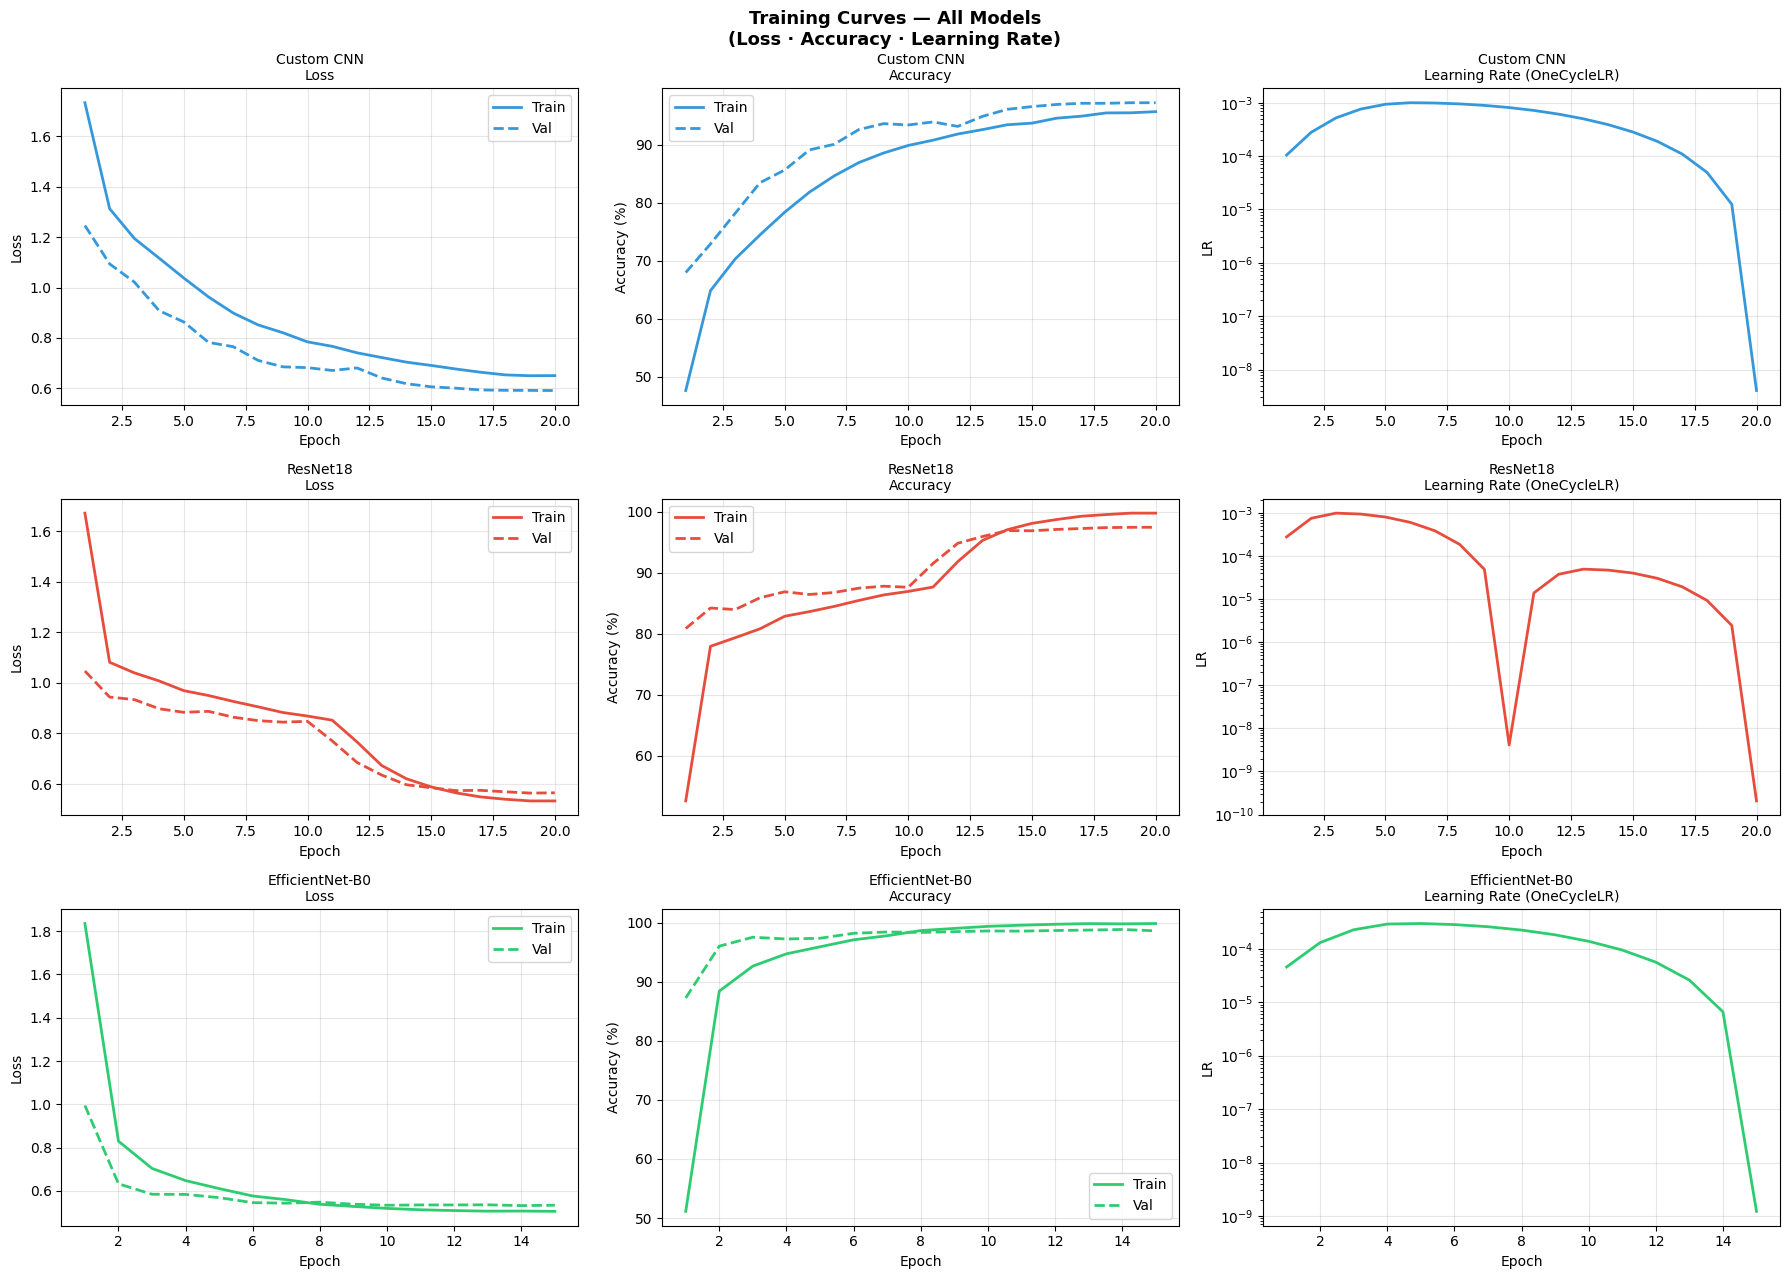

✅ Training curves saved.


In [14]:
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
fig.suptitle('Training Curves — All Models\n(Loss · Accuracy · Learning Rate)',
             fontsize=13, fontweight='bold')

colors = {'Custom CNN': '#3498DB', 'ResNet18': '#E74C3C', 'EfficientNet-B0': '#2ECC71'}

for row, (mname, hist) in enumerate(all_histories.items()):
    epochs = range(1, len(hist['train_loss']) + 1)
    color  = colors[mname]

    # Loss
    axes[row][0].plot(epochs, hist['train_loss'], color=color, lw=2, label='Train')
    axes[row][0].plot(epochs, hist['val_loss'],   color=color, lw=2, linestyle='--', label='Val')
    axes[row][0].set_title(f'{mname}\nLoss', fontsize=10)
    axes[row][0].set_xlabel('Epoch'); axes[row][0].set_ylabel('Loss')
    axes[row][0].legend(); axes[row][0].grid(True, alpha=0.3)

    # Accuracy
    axes[row][1].plot(epochs, hist['train_acc'], color=color, lw=2, label='Train')
    axes[row][1].plot(epochs, hist['val_acc'],   color=color, lw=2, linestyle='--', label='Val')
    axes[row][1].set_title(f'{mname}\nAccuracy', fontsize=10)
    axes[row][1].set_xlabel('Epoch'); axes[row][1].set_ylabel('Accuracy (%)')
    axes[row][1].legend(); axes[row][1].grid(True, alpha=0.3)

    # LR Schedule
    axes[row][2].plot(epochs, hist['lr'], color=color, lw=2)
    axes[row][2].set_title(f'{mname}\nLearning Rate (OneCycleLR)', fontsize=10)
    axes[row][2].set_xlabel('Epoch'); axes[row][2].set_ylabel('LR')
    axes[row][2].set_yscale('log'); axes[row][2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved.")


In [15]:
def evaluate_model(model, loader, class_names, model_name, device=device):
    """Full evaluation: OA, Kappa, IoU, F1, Confusion Matrix."""
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    oa    = accuracy_score(y_true, y_pred) * 100
    kappa = cohen_kappa_score(y_true, y_pred)
    f1    = f1_score(y_true, y_pred, average='macro') * 100
    iou   = jaccard_score(y_true, y_pred, average=None)

    print(f"\n{'='*55}")
    print(f" Evaluation Results — {model_name}")
    print(f"{'='*55}")
    print(f"  Overall Accuracy (OA)   : {oa:.2f}%")
    print(f"  Cohen's Kappa (κ)       : {kappa:.4f}  {'(Excellent ≥0.8)' if kappa>=0.8 else '(Good ≥0.6)' if kappa>=0.6 else ''}")
    print(f"  Macro F1 Score          : {f1:.2f}%")
    print(f"  Mean IoU                : {iou.mean()*100:.2f}%")
    print(f"\n  Per-Class IoU:")
    for cls, iou_val in zip(class_names, iou):
        bar = '█' * int(iou_val * 20)
        print(f"    {cls:<25} {iou_val:.3f}  {bar}")
    print()
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

    return y_true, y_pred, {'OA': oa, 'Kappa': kappa, 'F1': f1, 'MeanIoU': iou.mean()*100}


# ── Evaluate best model (EfficientNet-B0 typically) ──
y_true, y_pred, metrics_eff = evaluate_model(
    effnet_model, test_loader, CLASS_NAMES, "EfficientNet-B0"
)



 Evaluation Results — EfficientNet-B0
  Overall Accuracy (OA)   : 98.20%
  Cohen's Kappa (κ)       : 0.9799  (Excellent ≥0.8)
  Macro F1 Score          : 98.14%
  Mean IoU                : 96.37%

  Per-Class IoU:
    AnnualCrop                0.949  ██████████████████
    Forest                    0.986  ███████████████████
    HerbaceousVegetation      0.958  ███████████████████
    Highway                   0.963  ███████████████████
    Industrial                0.979  ███████████████████
    Pasture                   0.935  ██████████████████
    PermanentCrop             0.931  ██████████████████
    Residential               0.989  ███████████████████
    River                     0.966  ███████████████████
    SeaLake                   0.983  ███████████████████

                      precision    recall  f1-score   support

          AnnualCrop      0.971     0.977     0.974       472
              Forest      0.995     0.991     0.993       442
HerbaceousVegetation      0.97

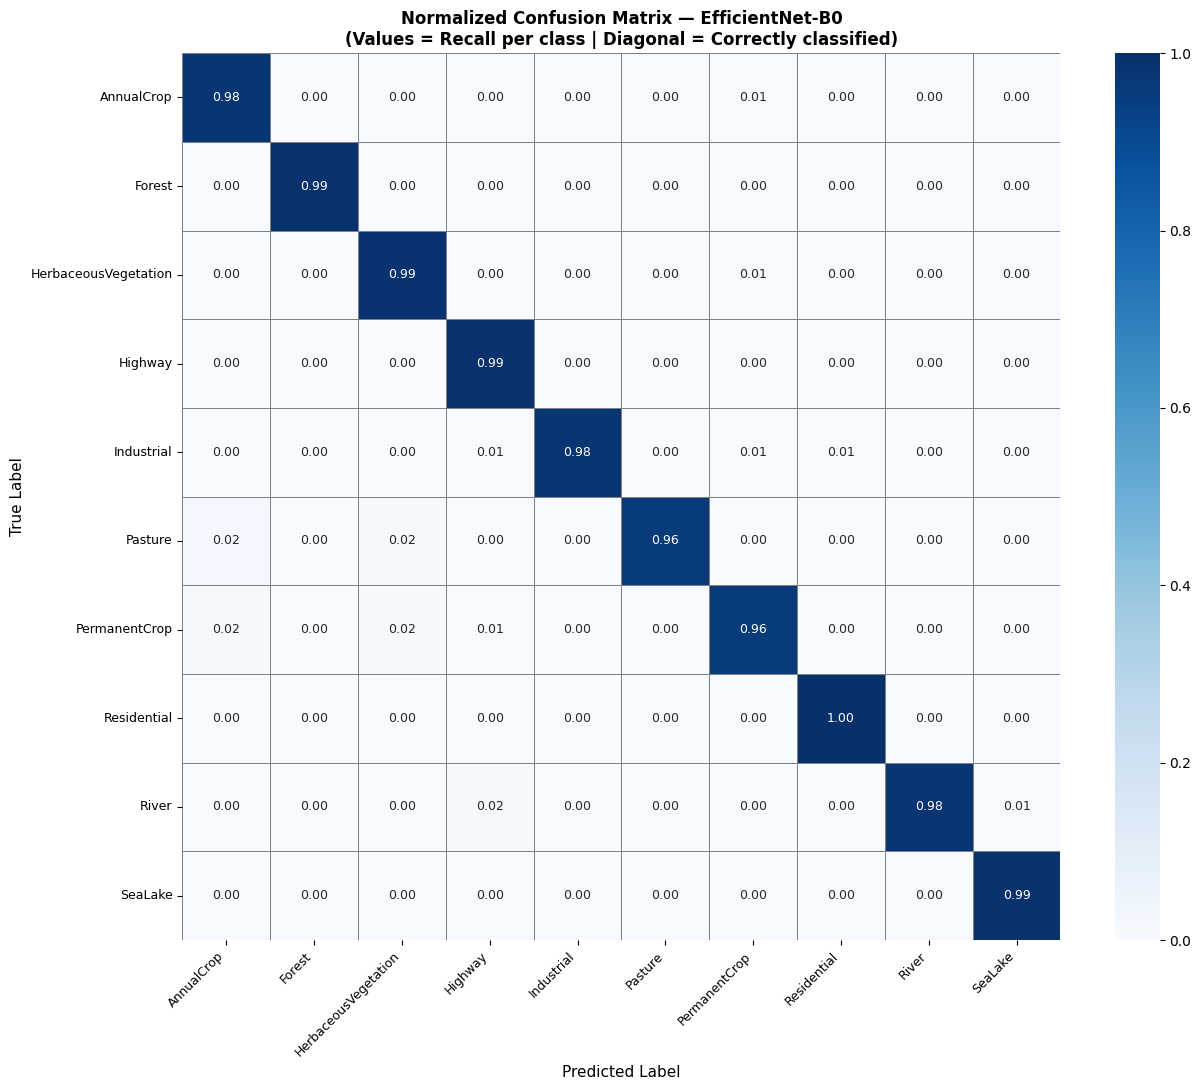

✅ Confusion matrix saved.


In [16]:
fig, ax = plt.subplots(figsize=(13, 11))
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize by row

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.5, linecolor='gray',
            annot_kws={'size': 9})

ax.set_title('Normalized Confusion Matrix — EfficientNet-B0\n'
             '(Values = Recall per class | Diagonal = Correctly classified)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label',      fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved.")


In [17]:
import torch.nn.functional as F_nn

class GradCAM:
    """
    Grad-CAM implementation for CNN spatial interpretability.
    Hoang et al. (2017) — Gradient-weighted Class Activation Mapping.
    """
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1.0
        output.backward(gradient=one_hot)

        # Compute Grad-CAM
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = F_nn.relu(cam)
        cam     = F_nn.interpolate(cam, size=(64, 64), mode='bilinear', align_corners=False)
        cam     = cam.squeeze().cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

# ── Attach Grad-CAM to ResNet18's last conv layer ──
grad_cam = GradCAM(resnet_model, resnet_model.layer4[1].conv2)
print("✅ Grad-CAM initialized on ResNet18 → layer4[1].conv2")


✅ Grad-CAM initialized on ResNet18 → layer4[1].conv2


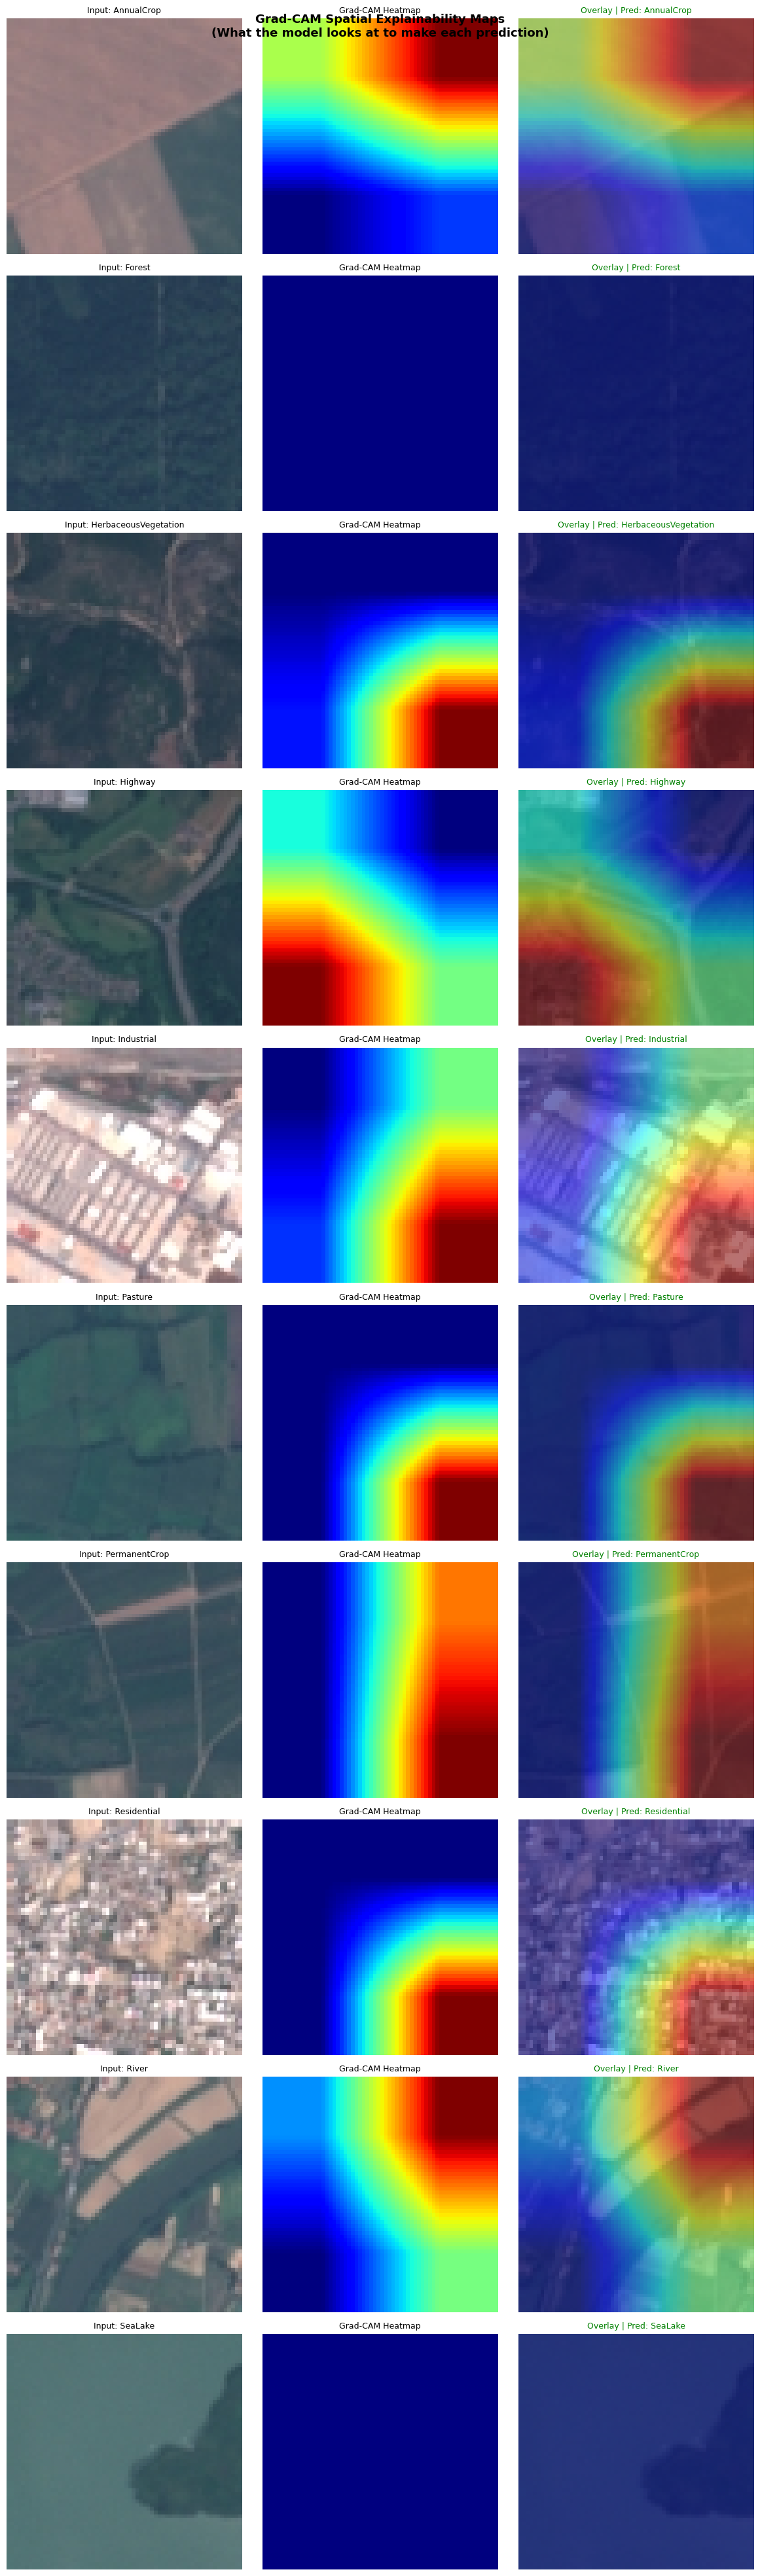

✅ Grad-CAM visualization saved.


In [18]:
# ── Visualize Grad-CAM for one sample per class ──
mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(len(CLASS_NAMES), 3, figsize=(12, 4*len(CLASS_NAMES)))
fig.suptitle('Grad-CAM Spatial Explainability Maps\n'
             '(What the model looks at to make each prediction)',
             fontsize=13, fontweight='bold')

resnet_model.eval()
for row, cls in enumerate(CLASS_NAMES):
    cls_dir  = os.path.join(DATA_PATH, cls)
    img_path = os.path.join(cls_dir, sorted(os.listdir(cls_dir))[10])
    pil_img  = Image.open(img_path).resize((64, 64)).convert('RGB')
    raw_np   = np.array(pil_img)

    # Preprocess
    tensor = val_transform(pil_img).unsqueeze(0).to(device)

    # Generate CAM
    cam, pred_idx = grad_cam.generate(tensor)
    pred_name     = CLASS_NAMES[pred_idx]
    is_correct    = (cls == pred_name)

    # Denormalize for display
    disp = (tensor.squeeze().cpu() * std_t + mean_t).permute(1,2,0).numpy()
    disp = np.clip(disp, 0, 1)

    # Heatmap overlay
    import matplotlib.cm as mpl_cm
    heatmap = mpl_cm.jet(cam)[:,:,:3]
    overlay = 0.45 * disp + 0.55 * heatmap

    axes[row][0].imshow(raw_np);  axes[row][0].set_title(f'Input: {cls}', fontsize=9); axes[row][0].axis('off')
    axes[row][1].imshow(cam, cmap='jet'); axes[row][1].set_title('Grad-CAM Heatmap', fontsize=9); axes[row][1].axis('off')
    axes[row][2].imshow(overlay); title_col = 'green' if is_correct else 'red'
    axes[row][2].set_title(f'Overlay | Pred: {pred_name}', fontsize=9, color=title_col)
    axes[row][2].axis('off')

plt.tight_layout()
plt.savefig('gradcam_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Grad-CAM visualization saved.")


In [19]:
from sklearn.manifold import TSNE

def extract_features(model, loader, layer_name='avgpool', max_samples=2000, device=device):
    """Extract deep features from ResNet's global average pool layer."""
    features, labels_list = [], []
    model.eval()

    # Hook to capture avgpool output
    feature_vec = []
    def hook_fn(module, input, output):
        feature_vec.append(output.squeeze(-1).squeeze(-1).detach().cpu())

    hook = resnet_model.avgpool.register_forward_hook(hook_fn)
    count = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            if count >= max_samples:
                break
            imgs = imgs.to(device)
            _ = model(imgs)
            labels_list.extend(lbls.numpy())
            count += imgs.size(0)

    hook.remove()
    feats = torch.cat(feature_vec, dim=0).numpy()[:max_samples]
    lbls  = np.array(labels_list)[:max_samples]
    return feats, lbls

print("Extracting features from ResNet18 (this may take ~1 min)...")
feats, feat_labels = extract_features(resnet_model, test_loader, max_samples=2000)
print(f"✅ Extracted features: {feats.shape} | Labels: {feat_labels.shape}")

print("Running t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=SEED, verbose=0)
feats_2d = tsne.fit_transform(feats)
print(f"✅ t-SNE complete. Shape: {feats_2d.shape}")


Extracting features from ResNet18 (this may take ~1 min)...
✅ Extracted features: (2000, 512) | Labels: (2000,)
Running t-SNE dimensionality reduction...
✅ t-SNE complete. Shape: (2000, 2)


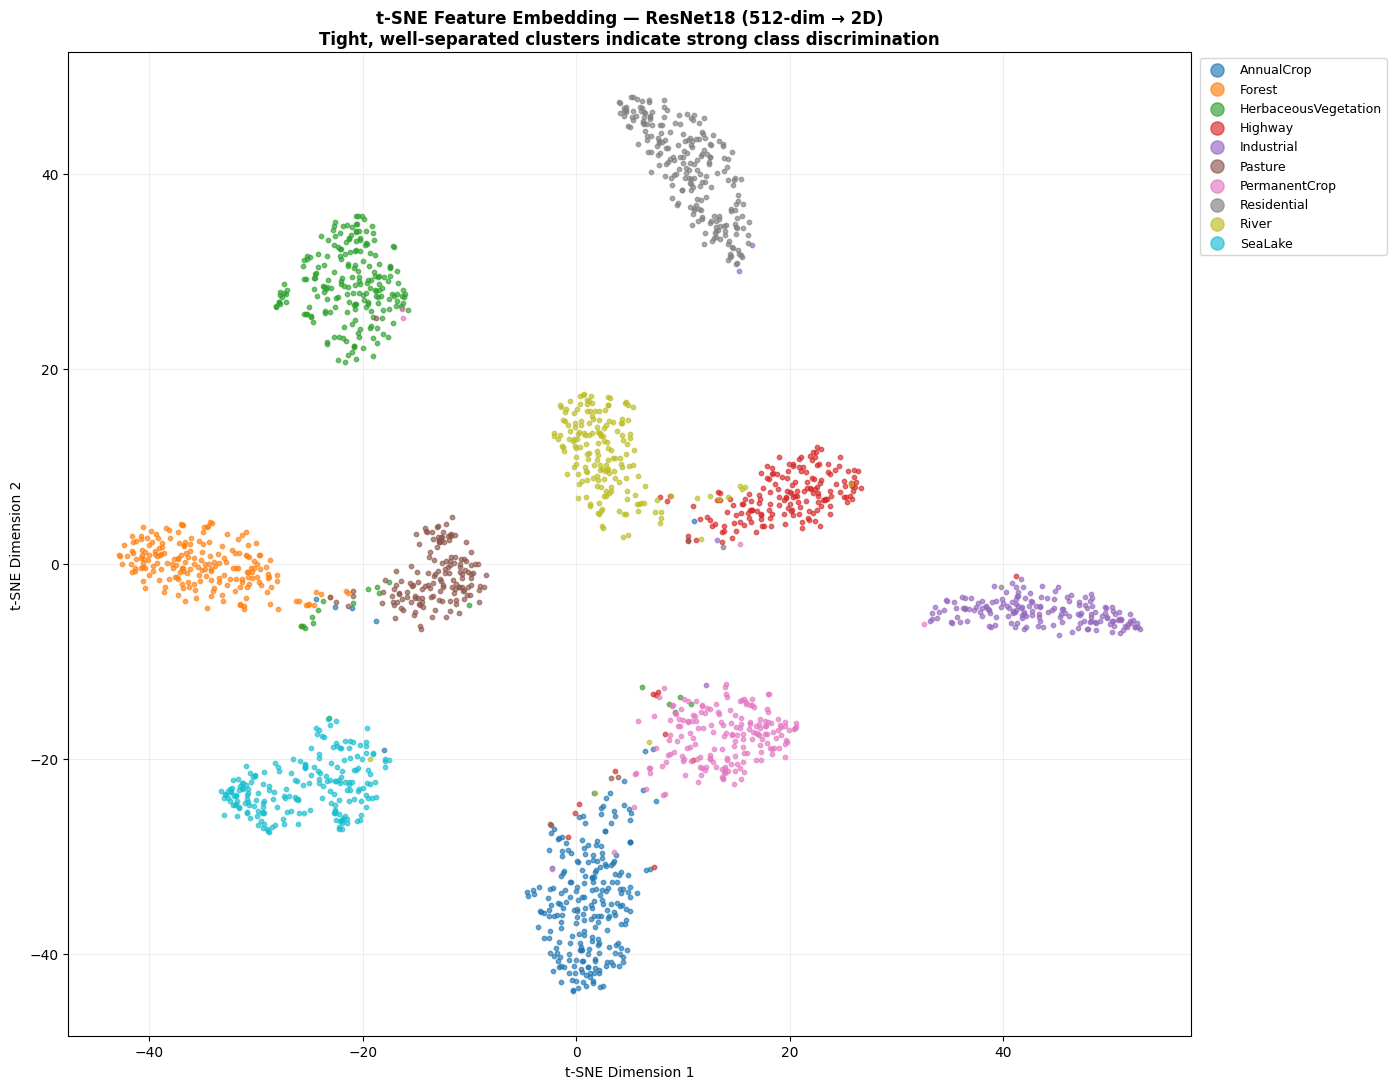

✅ t-SNE embedding saved.


In [20]:
fig, ax = plt.subplots(figsize=(14, 11))
colors_tsne = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

for idx, cls in enumerate(CLASS_NAMES):
    mask = feat_labels == idx
    ax.scatter(feats_2d[mask, 0], feats_2d[mask, 1],
               c=[colors_tsne[idx]], s=10, alpha=0.65, label=cls)

ax.set_title('t-SNE Feature Embedding — ResNet18 (512-dim → 2D)\n'
             'Tight, well-separated clusters indicate strong class discrimination',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', markerscale=3, fontsize=9,
          bbox_to_anchor=(1.18, 1.0))
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ t-SNE embedding saved.")


In [21]:
# ── Evaluate all models ──
print("Evaluating all models on test set...\n")

_, _, metrics_cnn = evaluate_model(cnn_model,    test_loader, CLASS_NAMES, "Custom CNN")
_, _, metrics_res = evaluate_model(resnet_model,  test_loader, CLASS_NAMES, "ResNet18")
_, _, metrics_eff = evaluate_model(effnet_model,  test_loader, CLASS_NAMES, "EfficientNet-B0")

# ── Params count ──
def count_params(m): return sum(p.numel() for p in m.parameters())

benchmark = {
    'Model': ['Custom CNN', 'ResNet18', 'EfficientNet-B0'],
    'OA (%)':    [metrics_cnn['OA'],       metrics_res['OA'],    metrics_eff['OA']],
    'Kappa':     [metrics_cnn['Kappa'],    metrics_res['Kappa'], metrics_eff['Kappa']],
    'F1 (%)':    [metrics_cnn['F1'],       metrics_res['F1'],    metrics_eff['F1']],
    'Mean IoU (%)': [metrics_cnn['MeanIoU'], metrics_res['MeanIoU'], metrics_eff['MeanIoU']],
    'Params (M)': [count_params(cnn_model)/1e6,
                   count_params(resnet_model)/1e6,
                   count_params(effnet_model)/1e6]
}

# ── Print table ──
print(f"\n{'='*75}")
print(f" {'Model':<22} {'OA (%)':>8} {'Kappa':>8} {'F1 (%)':>8} {'IoU (%)':>9} {'Params (M)':>11}")
print(f"{'─'*75}")
for i in range(3):
    best = '✅' if i == 2 else '  '
    print(f" {best} {benchmark['Model'][i]:<20} "
          f"{benchmark['OA (%)'][i]:>8.2f} "
          f"{benchmark['Kappa'][i]:>8.4f} "
          f"{benchmark['F1 (%)'][i]:>8.2f} "
          f"{benchmark['Mean IoU (%)'][i]:>9.2f} "
          f"{benchmark['Params (M)'][i]:>11.2f}")
print(f"{'='*75}")


Evaluating all models on test set...


 Evaluation Results — Custom CNN
  Overall Accuracy (OA)   : 96.44%
  Cohen's Kappa (κ)       : 0.9604  (Excellent ≥0.8)
  Macro F1 Score          : 96.38%
  Mean IoU                : 93.07%

  Per-Class IoU:
    AnnualCrop                0.914  ██████████████████
    Forest                    0.971  ███████████████████
    HerbaceousVegetation      0.896  █████████████████
    Highway                   0.948  ██████████████████
    Industrial                0.950  ███████████████████
    Pasture                   0.901  ██████████████████
    PermanentCrop             0.876  █████████████████
    Residential               0.967  ███████████████████
    River                     0.914  ██████████████████
    SeaLake                   0.969  ███████████████████

                      precision    recall  f1-score   support

          AnnualCrop      0.959     0.951     0.955       472
              Forest      0.984     0.986     0.985       442
He

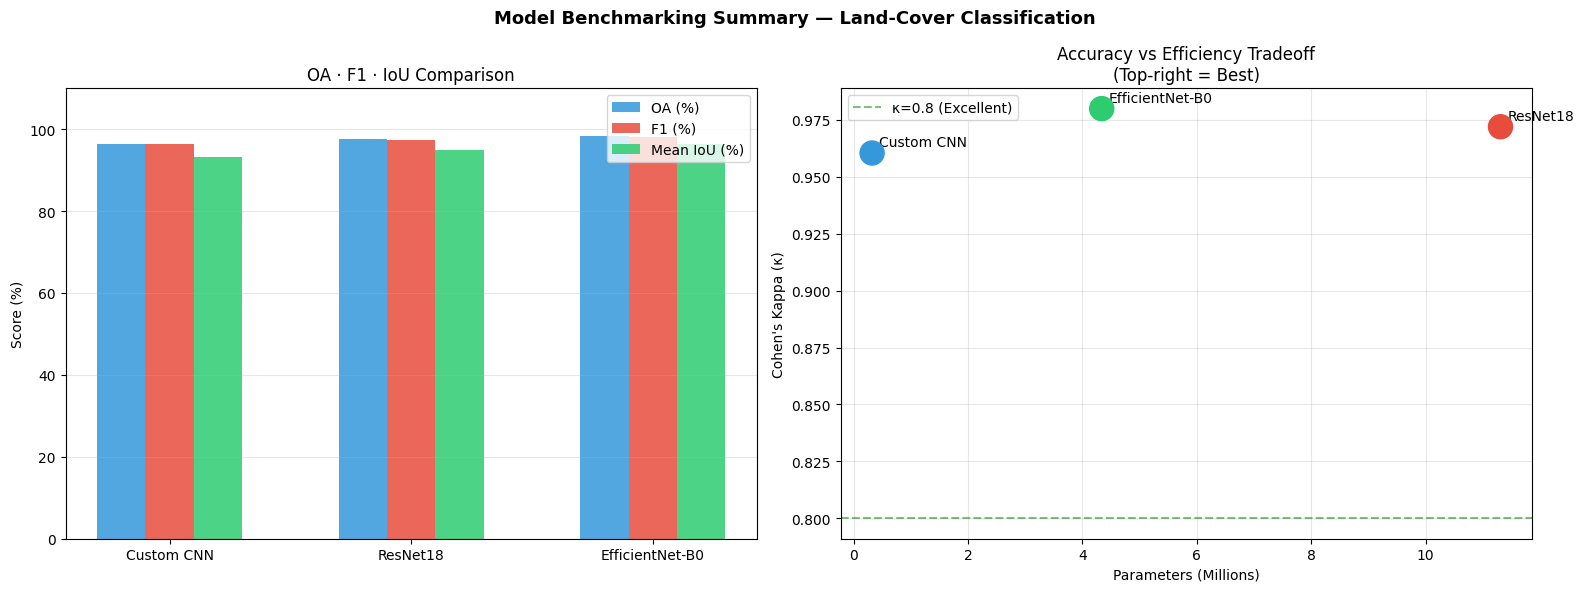

✅ Benchmark chart saved.


In [22]:
# ── Visual Benchmark Radar / Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Benchmarking Summary — Land-Cover Classification',
             fontsize=13, fontweight='bold')

x        = np.arange(3)
w        = 0.2
b_colors = ['#3498DB', '#E74C3C', '#2ECC71']
metrics_keys  = ['OA (%)', 'F1 (%)', 'Mean IoU (%)']
metric_vals   = [benchmark['OA (%)'], benchmark['F1 (%)'], benchmark['Mean IoU (%)']]

for i, (mk, mv) in enumerate(zip(metrics_keys, metric_vals)):
    axes[0].bar(x + i*w, mv, w, label=mk, color=b_colors[i], alpha=0.85)

axes[0].set_xticks(x + w)
axes[0].set_xticklabels(benchmark['Model'])
axes[0].set_ylabel('Score (%)')
axes[0].set_title('OA · F1 · IoU Comparison')
axes[0].legend()
axes[0].set_ylim(0, 110)
axes[0].grid(True, axis='y', alpha=0.3)

# Kappa vs Params
sc = axes[1].scatter(benchmark['Params (M)'], benchmark['Kappa'],
                     s=[300,300,300], c=b_colors, zorder=5)
for i, name in enumerate(benchmark['Model']):
    axes[1].annotate(name,
                     (benchmark['Params (M)'][i], benchmark['Kappa'][i]),
                     xytext=(5, 5), textcoords='offset points', fontsize=10)
axes[1].set_xlabel('Parameters (Millions)')
axes[1].set_ylabel("Cohen's Kappa (κ)")
axes[1].set_title("Accuracy vs Efficiency Tradeoff\n(Top-right = Best)")
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0.8, color='green', ls='--', alpha=0.5, label='κ=0.8 (Excellent)')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Benchmark chart saved.")


## 13. Prediction Visualization & Error Analysis

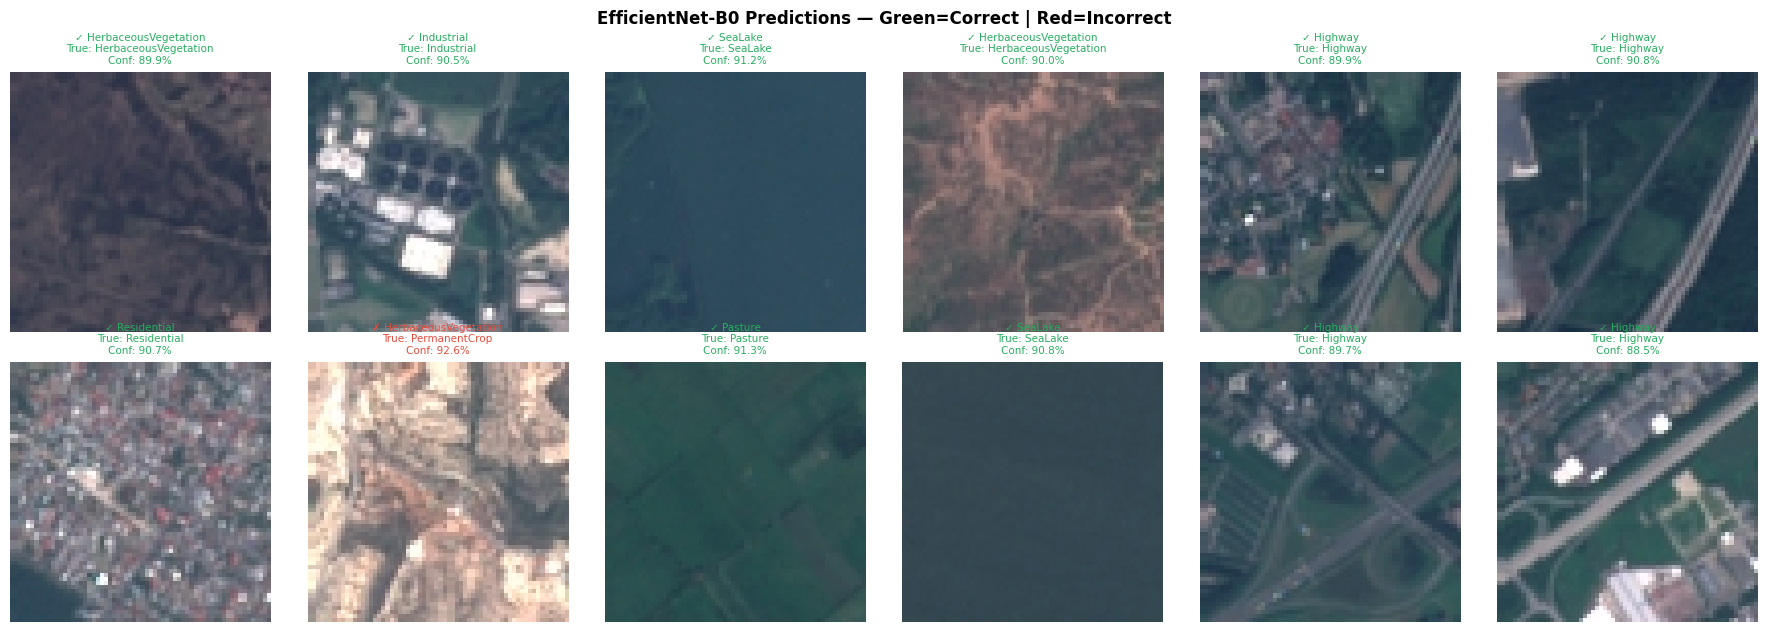

✅ Prediction grid saved.


In [23]:
def visualize_predictions_grid(model, loader, class_names, title, n=12, device=device):
    """Show predictions with confidence scores and correct/incorrect coloring."""
    model.eval()
    images_shown, labels_shown, preds_shown, confs_shown = [], [], [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            outputs  = model(imgs)
            probs    = torch.softmax(outputs, dim=1)
            confs, preds = probs.max(1)
            images_shown.extend(imgs.cpu())
            labels_shown.extend(lbls.numpy())
            preds_shown.extend(preds.cpu().numpy())
            confs_shown.extend(confs.cpu().numpy())
            if len(images_shown) >= n:
                break

    mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    cols = 6
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3.2))
    fig.suptitle(title, fontsize=12, fontweight='bold')

    for i in range(n):
        ax  = axes[i // cols][i % cols]
        img = (images_shown[i] * std_t + mean_t).permute(1,2,0).numpy()
        img = np.clip(img, 0, 1)

        correct = (labels_shown[i] == preds_shown[i])
        color   = '#27AE60' if correct else '#E74C3C'
        marker  = '✓' if correct else '✗'

        ax.imshow(img)
        ax.set_title(f"{marker} {class_names[preds_shown[i]]}\n"
                     f"True: {class_names[labels_shown[i]]}\n"
                     f"Conf: {confs_shown[i]*100:.1f}%",
                     fontsize=7.5, color=color)
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
            spine.set_visible(True)

    plt.tight_layout()
    plt.savefig('prediction_grid.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Prediction grid saved.")

visualize_predictions_grid(effnet_model, test_loader, CLASS_NAMES,
                           'EfficientNet-B0 Predictions — Green=Correct | Red=Incorrect', n=12)


🔍 Top-10 Most Confused Class Pairs (True → Predicted):

  True Class             Predicted As            Count
  ────────────────────────────────────────────────────
  PermanentCrop          HerbaceousVegetation        7
  Pasture                AnnualCrop                  7
  River                  Highway                     6
  PermanentCrop          AnnualCrop                  6
  Pasture                HerbaceousVegetation        5
  Industrial             Residential                 4
  AnnualCrop             PermanentCrop               4
  HerbaceousVegetation   PermanentCrop               3
  SeaLake                River                       2
  River                  SeaLake                     2


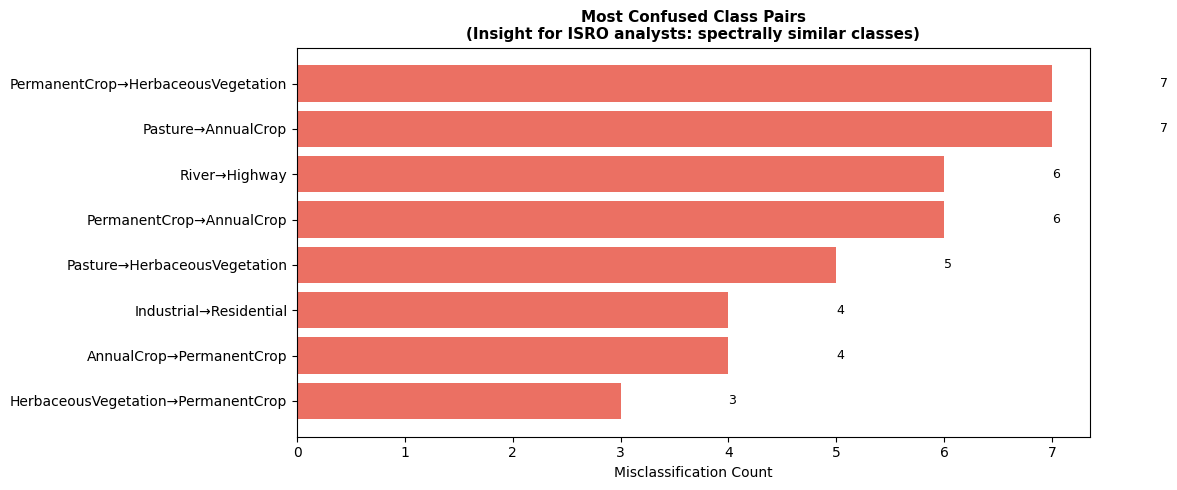

In [24]:
# ── Show which class pairs are most confused ──
cm = confusion_matrix(y_true, y_pred)
np.fill_diagonal(cm, 0)  # Remove correct predictions

# Find top-5 confusion pairs
confusion_pairs = []
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        if i != j and cm[i][j] > 0:
            confusion_pairs.append((cm[i][j], CLASS_NAMES[i], CLASS_NAMES[j]))

confusion_pairs.sort(reverse=True)
print("🔍 Top-10 Most Confused Class Pairs (True → Predicted):")
print(f"\n  {'True Class':<22} {'Predicted As':<22} {'Count':>6}")
print(f"  {'─'*52}")
for count, true_cls, pred_cls in confusion_pairs[:10]:
    print(f"  {true_cls:<22} {pred_cls:<22} {count:>6}")

# ── Visual ──
top_pairs    = confusion_pairs[:8]
pair_labels  = [f"{t}→{p}" for _, t, p in top_pairs]
pair_counts  = [c for c, _, _ in top_pairs]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(pair_labels, pair_counts, color='#E74C3C', alpha=0.8)
ax.set_xlabel('Misclassification Count')
ax.set_title('Most Confused Class Pairs\n(Insight for ISRO analysts: spectrally similar classes)',
             fontsize=11, fontweight='bold')
for bar, count in zip(bars, pair_counts):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('confusion_pairs.png', dpi=150, bbox_inches='tight')
plt.show()


In [26]:
!pip install onnxscript -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 8.5 MB/s eta 0:00:00


## 14. Model Export & Deployment Notes

In [27]:
import torch.onnx

# ── Save PyTorch checkpoint ──
torch.save({
    'model_state_dict': effnet_model.state_dict(),
    'class_names':      CLASS_NAMES,
    'num_classes':      NUM_CLASSES,
    'input_size':       (3, IMG_SIZE, IMG_SIZE),
    'normalization':    {'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225]},
    'metrics':          metrics_eff,
}, 'satellite_classifier_efficientnet_b0.pth')
print("✅ PyTorch checkpoint saved: satellite_classifier_efficientnet_b0.pth")

# ── Export to ONNX (for edge deployment on ISRO ground systems) ──
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
torch.onnx.export(
    effnet_model, dummy_input,
    "satellite_classifier.onnx",
    export_params=True,
    opset_version=11,
    input_names=['satellite_image'],
    output_names=['land_cover_logits'],
    dynamic_axes={'satellite_image': {0: 'batch_size'}}
)
print("✅ ONNX model exported: satellite_classifier.onnx")
print("   → Ready for deployment on ISRO edge systems / Bhuvan API integration")

# ── Quick inference demo ──
def predict_single(model, image_path, class_names, device=device):
    """Single image inference with confidence scores."""
    img    = Image.open(image_path).convert('RGB')
    tensor = val_transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(tensor)
        probs   = torch.softmax(outputs, dim=1)[0]
    top3    = probs.topk(3)
    print(f"\n🛰️  Inference Result:")
    for i in range(3):
        print(f"   #{i+1}: {class_names[top3.indices[i].item()]:<22} "
              f"({top3.values[i].item()*100:.2f}%)")
    return class_names[probs.argmax().item()]

# Test on a Forest image
test_path = os.path.join(DATA_PATH, 'Forest', sorted(os.listdir(os.path.join(DATA_PATH,'Forest')))[0])
pred = predict_single(effnet_model, test_path, CLASS_NAMES)
print(f"\n   Final Prediction: {pred}")


✅ PyTorch checkpoint saved: satellite_classifier_efficientnet_b0.pth


W0308 11:26:47.038000 516 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0308 11:26:52.999000 516 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0308 11:26:53.016000 516 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, 

[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

[torch.onnx] Translate the graph into ONNX... ✅
Applied 99 of general pattern rewrite rules.
✅ ONNX model exported: satellite_classifier.onnx
   → Ready for deployment on ISRO edge systems / Bhuvan API integration

🛰️  Inference Result:
   #1: Forest                 (90.16%)
   #2: AnnualCrop             (1.16%)
   #3: HerbaceousVegetation   (1.14%)

   Final Prediction: Forest
